In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
import torchvision.transforms as transforms
from torchvision import datasets
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# =========================================================
# DEVICE
# =========================================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# =========================================================
# DATA AUGMENTATION & TRANSFORMS
# =========================================================

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# =========================================================
# LOAD DATASET
# =========================================================

full_dataset = datasets.ImageFolder(
    root="dataset",
    transform=eval_transform
)

dataset_size = len(full_dataset)
train_size = int(0.7 * dataset_size)
val_size = int(0.15 * dataset_size)
test_size = dataset_size - train_size - val_size

generator = torch.Generator().manual_seed(42)
indices = torch.randperm(dataset_size, generator=generator).tolist()
train_indices = indices[:train_size]
val_indices = indices[train_size:train_size + val_size]
test_indices = indices[train_size + val_size:]

train_dataset = Subset(
    datasets.ImageFolder(root="dataset", transform=train_transform),
    train_indices
)

val_dataset = Subset(
    datasets.ImageFolder(root="dataset", transform=eval_transform),
    val_indices
)

test_dataset = Subset(
    datasets.ImageFolder(root="dataset", transform=eval_transform),
    test_indices
)

# =========================================================
# DATALOADERS
# =========================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

# =========================================================
# INFO
# =========================================================

num_classes = len(full_dataset.classes)

print("Classes:", full_dataset.classes)
print("Number of classes:", num_classes)
print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))


Using device: cpu
Classes: ['Angry', 'Other', 'Sad', 'happy']
Number of classes: 4
Train size: 700
Validation size: 150
Test size: 150


Epoch [1/20]: 100%|██████████| 22/22 [01:25<00:00,  3.88s/it, loss=1.42]



Epoch 1/20
Train Loss: 1.4540
Train Accuracy: 28.71%
Validation Loss: 1.3738
Validation Accuracy: 30.67%


Epoch [2/20]: 100%|██████████| 22/22 [01:21<00:00,  3.72s/it, loss=1.45]



Epoch 2/20
Train Loss: 1.4574
Train Accuracy: 26.86%
Validation Loss: 1.4106
Validation Accuracy: 24.67%


Epoch [3/20]: 100%|██████████| 22/22 [01:22<00:00,  3.75s/it, loss=1.51]


...


Epoch 18/20
Train Loss: 1.2204
Train Accuracy: 44.14%
Validation Loss: 1.3208
Validation Accuracy: 42.67%


Epoch [19/20]: 100%|██████████| 22/22 [01:33<00:00,  4.26s/it, loss=1.16]



Epoch 19/20
Train Loss: 1.1950
Train Accuracy: 47.14%
Validation Loss: 1.2987
Validation Accuracy: 42.00%


Epoch [20/20]: 100%|██████████| 22/22 [01:33<00:00,  4.26s/it, loss=1.29]



Epoch 20/20
Train Loss: 1.2213
Train Accuracy: 44.14%
Validation Loss: 1.3531
Validation Accuracy: 39.33%

================ RESULTS ================

Accuracy  : 36.67%
Weighted Precision : 0.3578
Weighted Recall    : 0.3667
Weighted F1 Score  : 0.3525

Classification Report:

Class                Precision    Recall  F1-score   Support
------------------------------------------------------------
Angry                   0.4237    0.6098    0.5000        41
Other                   0.3125    0.3333    0.3226        30
Sad                     0.3333    0.2955    0.3133        44
happy                   0.3500    0.2000    0.2545        35


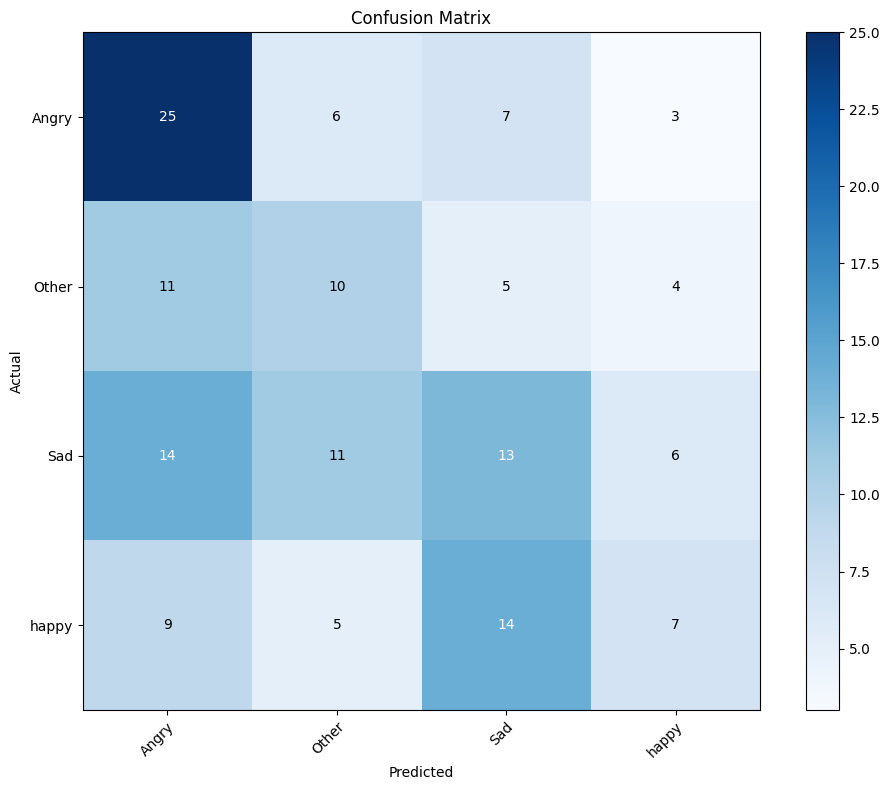


MobileNet Model Saved!


In [8]:
# =========================================================
# MOBILE NET FROM SCRATCH
# =========================================================

class DepthwiseSeparableConv(nn.Module):

    def __init__(self, in_channels, out_channels, stride=1):

        super(DepthwiseSeparableConv, self).__init__()

        self.depthwise = nn.Sequential(

            nn.Conv2d(
                in_channels,
                in_channels,
                kernel_size=3,
                stride=stride,
                padding=1,
                groups=in_channels,
                bias=False
            ),

            nn.BatchNorm2d(in_channels),

            nn.ReLU(inplace=True)
        )

        self.pointwise = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=1,
                bias=False
            ),

            nn.BatchNorm2d(out_channels),

            nn.ReLU(inplace=True)
        )

    def forward(self, x):

        x = self.depthwise(x)

        x = self.pointwise(x)

        return x

# =========================================================
# MOBILE NET MODEL
# =========================================================

class MobileNet(nn.Module):

    def __init__(self, num_classes):

        super(MobileNet, self).__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                3,
                32,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(inplace=True),

            DepthwiseSeparableConv(32, 64, 1),

            DepthwiseSeparableConv(64, 128, 2),
            DepthwiseSeparableConv(128, 128, 1),

            DepthwiseSeparableConv(128, 256, 2),
            DepthwiseSeparableConv(256, 256, 1),

            DepthwiseSeparableConv(256, 512, 2),

            DepthwiseSeparableConv(512, 512, 1),
            DepthwiseSeparableConv(512, 512, 1),
            DepthwiseSeparableConv(512, 512, 1),
            DepthwiseSeparableConv(512, 512, 1),
            DepthwiseSeparableConv(512, 512, 1),

            DepthwiseSeparableConv(512, 1024, 2),

            DepthwiseSeparableConv(1024, 1024, 1)
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(1024, num_classes)

    def forward(self, x):

        x = self.features(x)

        x = self.pool(x)

        x = torch.flatten(x, 1)

        x = self.dropout(x)

        x = self.fc(x)

        return x

# =========================================================
# CREATE MODEL
# =========================================================

mobilenet_model = MobileNet(num_classes=num_classes).to(device)

# =========================================================
# LOSS FUNCTION
# =========================================================

criterion = nn.CrossEntropyLoss()

# =========================================================
# OPTIMIZER
# =========================================================

mobilenet_optimizer = optim.Adam(
    mobilenet_model.parameters(),
    lr=0.001
)

# =========================================================
# TRAIN FUNCTION
# =========================================================

def train_model(model, optimizer, train_loader, val_loader, epochs):

    train_losses = []
    val_losses = []

    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):

        model.train()

        running_loss = 0
        correct = 0
        total = 0

        loop = tqdm(train_loader)

        for images, labels in loop:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            loop.set_description(f"Epoch [{epoch+1}/{epochs}]")
            loop.set_postfix(loss=loss.item())

        train_loss = running_loss / len(train_loader)
        train_accuracy = 100 * correct / total

        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)

        model.eval()

        val_loss = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss = val_loss / len(val_loader)
        val_accuracy = 100 * val_correct / val_total

        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"Train Loss: {train_loss:.4f}")
        print(f"Train Accuracy: {train_accuracy:.2f}%")
        print(f"Validation Loss: {val_loss:.4f}")
        print(f"Validation Accuracy: {val_accuracy:.2f}%")

    return train_losses, val_losses, train_accuracies, val_accuracies

# =========================================================
# METRICS HELPERS
# =========================================================

def compute_confusion_matrix(labels, preds, num_classes):
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for true, pred in zip(labels, preds):
        cm[true, pred] += 1
    return cm


def compute_precision_recall_f1(cm):
    tp = np.diag(cm).astype(float)
    support = cm.sum(axis=1).astype(float)
    predicted = cm.sum(axis=0).astype(float)

    precision = np.divide(tp, predicted, out=np.zeros_like(tp), where=predicted != 0)
    recall = np.divide(tp, support, out=np.zeros_like(tp), where=support != 0)
    f1 = np.divide(
        2 * precision * recall,
        precision + recall,
        out=np.zeros_like(precision),
        where=(precision + recall) != 0
    )

    total = support.sum()
    weighted_precision = np.dot(precision, support) / total if total > 0 else 0.0
    weighted_recall = np.dot(recall, support) / total if total > 0 else 0.0
    weighted_f1 = np.dot(f1, support) / total if total > 0 else 0.0

    return precision, recall, f1, weighted_precision, weighted_recall, weighted_f1


def format_classification_report(cm, class_names):
    precision, recall, f1, _, _, _ = compute_precision_recall_f1(cm)
    support = cm.sum(axis=1)

    lines = []
    lines.append(f"{'Class':<20}{'Precision':>10}{'Recall':>10}{'F1-score':>10}{'Support':>10}")
    lines.append('-' * 60)

    for idx, label in enumerate(class_names):
        lines.append(
            f"{label:<20}{precision[idx]:>10.4f}{recall[idx]:>10.4f}{f1[idx]:>10.4f}{support[idx]:>10d}"
        )

    return '\n'.join(lines)

# =========================================================
# EVALUATION FUNCTION
# =========================================================
def evaluate_model(model, test_loader, class_names):

    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    cm = compute_confusion_matrix(all_labels, all_preds, len(class_names))
    precision, recall, f1, weighted_precision, weighted_recall, weighted_f1 = compute_precision_recall_f1(cm)
    accuracy = 100 * np.mean(np.array(all_preds) == np.array(all_labels))

    print("\n================ RESULTS ================\n")
    print(f"Accuracy  : {accuracy:.2f}%")
    print(f"Weighted Precision : {weighted_precision:.4f}")
    print(f"Weighted Recall    : {weighted_recall:.4f}")
    print(f"Weighted F1 Score  : {weighted_f1:.4f}\n")

    print("Classification Report:\n")
    print(format_classification_report(cm, class_names))

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    fig.colorbar(im, ax=ax)

    ax.set(
        xticks=np.arange(len(class_names)),
        yticks=np.arange(len(class_names)),
        xticklabels=class_names,
        yticklabels=class_names,
        ylabel='Actual',
        xlabel='Predicted',
        title='Confusion Matrix'
    )

    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

    thresh = cm.max() / 2.0 if cm.max() > 0 else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            color = 'white' if cm[i, j] > thresh else 'black'
            ax.text(j, i, format(cm[i, j], 'd'), ha='center', va='center', color=color)

    plt.tight_layout()
    plt.show()

# =========================================================
# TRAIN MOBILE NET
# =========================================================

mobilenet_train_losses, mobilenet_val_losses, mobilenet_train_acc, mobilenet_val_acc = train_model(
    mobilenet_model,
    mobilenet_optimizer,
    train_loader,
    val_loader,
    epochs=20
)

# =========================================================
# EVALUATE MOBILE NET
# =========================================================

evaluate_model(
    mobilenet_model,
    test_loader,
    full_dataset.classes
)

# =========================================================
# SAVE MODEL
# =========================================================

torch.save(
    mobilenet_model.state_dict(),
    "mobilenet_scratch.pth"
)

print("\nMobileNet Model Saved!")


Epoch [1/20]: 100%|██████████| 22/22 [01:31<00:00,  4.16s/it, loss=1.32]



Epoch 1/20
Train Loss: 1.4504
Train Accuracy: 24.57%
Validation Loss: 1.4041
Validation Accuracy: 23.33%


Epoch [2/20]: 100%|██████████| 22/22 [01:23<00:00,  3.81s/it, loss=1.51]



Epoch 2/20
Train Loss: 1.3925
Train Accuracy: 30.00%
Validation Loss: 1.4123
Validation Accuracy: 34.00%


Epoch [3/20]: 100%|██████████| 22/22 [01:25<00:00,  3.89s/it, loss=1.31]


...


Epoch 18/20
Train Loss: 1.2229
Train Accuracy: 42.86%
Validation Loss: 1.2747
Validation Accuracy: 42.67%


Epoch [19/20]: 100%|██████████| 22/22 [01:20<00:00,  3.67s/it, loss=1.3] 



Epoch 19/20
Train Loss: 1.2102
Train Accuracy: 44.14%
Validation Loss: 1.3924
Validation Accuracy: 39.33%


Epoch [20/20]: 100%|██████████| 22/22 [01:20<00:00,  3.67s/it, loss=1.21]



Epoch 20/20
Train Loss: 1.2073
Train Accuracy: 42.86%
Validation Loss: 1.2340
Validation Accuracy: 44.67%

================ RESULTS ================

Accuracy  : 42.67%
Weighted Precision : 0.5104
Weighted Recall    : 0.4267
Weighted F1 Score  : 0.4181

Classification Report:

Class                Precision    Recall  F1-score   Support
------------------------------------------------------------
Angry                   0.8333    0.2439    0.3774        41
Other                   0.3667    0.3667    0.3667        30
Sad                     0.4062    0.5909    0.4815        44
happy                   0.3864    0.4857    0.4304        35


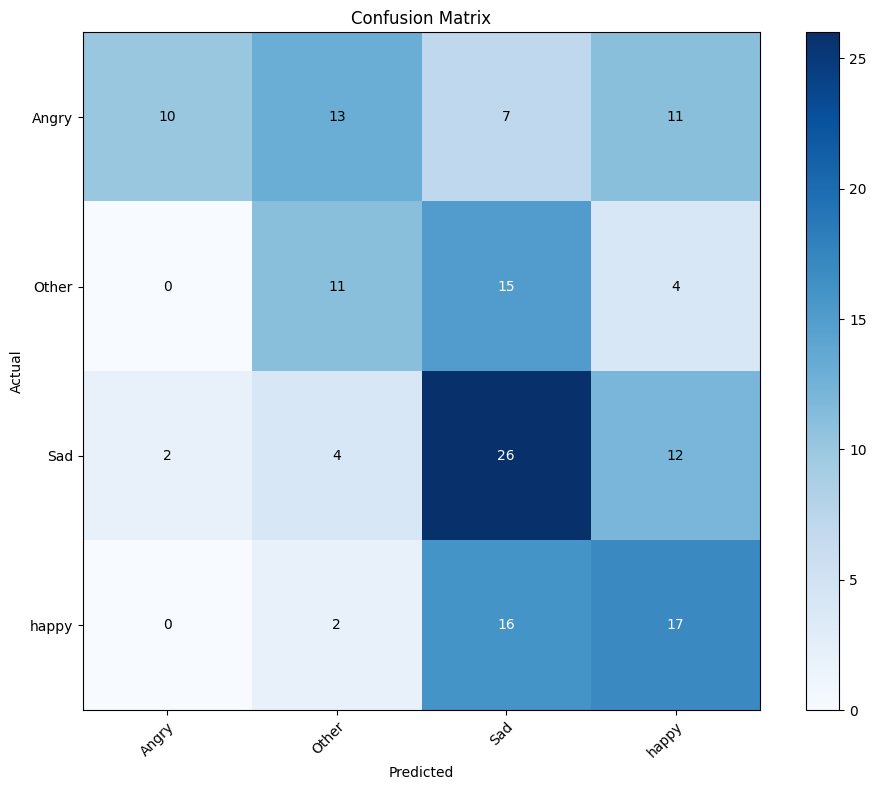


InceptionV3 Model Saved!


In [9]:
# =========================================================
# INCEPTION BLOCK
# =========================================================

class InceptionBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        out1x1,
        red3x3,
        out3x3,
        red5x5,
        out5x5,
        out_pool
    ):

        super(InceptionBlock, self).__init__()

        # ================= 1x1 BRANCH =================

        self.branch1 = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out1x1,
                kernel_size=1
            ),

            nn.BatchNorm2d(out1x1),

            nn.ReLU(inplace=True)
        )

        # ================= 3x3 BRANCH =================

        self.branch2 = nn.Sequential(

            nn.Conv2d(
                in_channels,
                red3x3,
                kernel_size=1
            ),

            nn.BatchNorm2d(red3x3),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                red3x3,
                out3x3,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(out3x3),

            nn.ReLU(inplace=True)
        )

        # ================= 5x5 BRANCH =================

        self.branch3 = nn.Sequential(

            nn.Conv2d(
                in_channels,
                red5x5,
                kernel_size=1
            ),

            nn.BatchNorm2d(red5x5),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                red5x5,
                out5x5,
                kernel_size=5,
                padding=2
            ),

            nn.BatchNorm2d(out5x5),

            nn.ReLU(inplace=True)
        )

        # ================= POOLING BRANCH =================

        self.branch4 = nn.Sequential(

            nn.MaxPool2d(
                kernel_size=3,
                stride=1,
                padding=1
            ),

            nn.Conv2d(
                in_channels,
                out_pool,
                kernel_size=1
            ),

            nn.BatchNorm2d(out_pool),

            nn.ReLU(inplace=True)
        )

    def forward(self, x):

        branch1 = self.branch1(x)

        branch2 = self.branch2(x)

        branch3 = self.branch3(x)

        branch4 = self.branch4(x)

        return torch.cat(
            [branch1, branch2, branch3, branch4],
            1
        )

# =========================================================
# INCEPTION V3 MODEL
# =========================================================

class InceptionV3(nn.Module):

    def __init__(self, num_classes):

        super(InceptionV3, self).__init__()

        self.initial = nn.Sequential(

            nn.Conv2d(
                3,
                32,
                kernel_size=3,
                stride=2,
                padding=1
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),

            nn.ReLU(inplace=True),

            nn.MaxPool2d(
                kernel_size=3,
                stride=2,
                padding=1
            ),

            nn.Conv2d(
                64,
                80,
                kernel_size=1
            ),

            nn.BatchNorm2d(80),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                80,
                192,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(192),

            nn.ReLU(inplace=True),

            nn.MaxPool2d(
                kernel_size=3,
                stride=2,
                padding=1
            )
        )

        # ================= INCEPTION MODULES =================

        self.inception1 = InceptionBlock(
            192,
            64,
            96,
            128,
            16,
            32,
            32
        )

        self.inception2 = InceptionBlock(
            256,
            128,
            128,
            192,
            32,
            96,
            64
        )

        self.inception3 = InceptionBlock(
            480,
            192,
            96,
            208,
            16,
            48,
            64
        )

        # Output channels:
        # 192 + 208 + 48 + 64 = 512

        self.avgpool = nn.AdaptiveAvgPool2d((1,1))

        self.dropout = nn.Dropout(0.5)

        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):

        x = self.initial(x)

        x = self.inception1(x)

        x = self.inception2(x)

        x = self.inception3(x)

        x = self.avgpool(x)

        x = torch.flatten(x, 1)

        x = self.dropout(x)

        x = self.fc(x)

        return x

# =========================================================
# CREATE MODEL
# =========================================================

inception_model = InceptionV3(
    num_classes=num_classes
).to(device)

# =========================================================
# OPTIMIZER
# =========================================================

inception_optimizer = optim.Adam(
    inception_model.parameters(),
    lr=0.001
)

# =========================================================
# TRAIN INCEPTION V3
# =========================================================

inception_train_losses, inception_val_losses, inception_train_acc, inception_val_acc = train_model(
    inception_model,
    inception_optimizer,
    train_loader,
    val_loader,
    epochs=20
)

# =========================================================
# EVALUATE INCEPTION V3
# =========================================================

evaluate_model(
    inception_model,
    test_loader,
    train_dataset.dataset.classes
)

# =========================================================
# SAVE MODEL
# =========================================================

torch.save(
    inception_model.state_dict(),
    "inceptionv3_scratch.pth"
)

print("\nInceptionV3 Model Saved!")